In [14]:
import torch
torch.cuda.is_available()

True

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
!cp /content/drive/MyDrive/caltech-101.zip .
!unzip -q caltech-101.zip

In [22]:
import shutil, os
bg = "caltech-101/BACKGROUND_Google"
if os.path.exists(bg):
    shutil.rmtree(bg)

In [23]:
import numpy as np
from torchvision import datasets

dataset = datasets.ImageFolder("caltech-101")
targets = np.array([y for _, y in dataset.samples])
num_classes = len(dataset.classes)
print("Classes:", num_classes)

rng = np.random.default_rng(42)

train_idx, val_idx, test_idx = [], [], []

for c in range(num_classes):
    idx = np.where(targets == c)[0]
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_idx.extend(idx[:n_train])
    val_idx.extend(idx[n_train:n_train+n_val])
    test_idx.extend(idx[n_train+n_val:])

print(len(train_idx), len(val_idx), len(test_idx), "total:", len(dataset))

Classes: 101
6026 1256 1395 total: 8677


In [24]:
from torchvision import transforms
from torch.utils.data import Subset, DataLoader

IMAGE_SIZE = 128
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_base = datasets.ImageFolder("caltech-101", transform=train_tf)
eval_base  = datasets.ImageFolder("caltech-101", transform=eval_tf)

train_ds = Subset(train_base, train_idx)
val_ds   = Subset(eval_base,  val_idx)
test_ds  = Subset(eval_base,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

num_classes = len(train_base.classes)
class_names = train_base.classes

In [25]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s] 


In [26]:
import torch
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def eval_acc(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

EPOCHS = 5
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running += loss.item()

    avg_loss = running / len(train_loader)
    v_acc = eval_acc(val_loader)
    train_losses.append(avg_loss)
    val_accs.append(v_acc)

    print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_acc={v_acc:.4f}")

Epoch 1/5: 100%|██████████| 189/189 [00:16<00:00, 11.19it/s]


Epoch 1: train_loss=1.7731, val_acc=0.8662


Epoch 2/5: 100%|██████████| 189/189 [00:15<00:00, 12.11it/s]


Epoch 2: train_loss=0.4066, val_acc=0.9084


Epoch 3/5: 100%|██████████| 189/189 [00:17<00:00, 10.67it/s]


Epoch 3: train_loss=0.1668, val_acc=0.9212


Epoch 4/5: 100%|██████████| 189/189 [00:16<00:00, 11.41it/s]


Epoch 4: train_loss=0.0820, val_acc=0.9315


Epoch 5/5: 100%|██████████| 189/189 [00:16<00:00, 11.77it/s]


Epoch 5: train_loss=0.0443, val_acc=0.9323


In [27]:
import numpy as np
import torch
from sklearn.metrics import classification_report, accuracy_score
import os

os.makedirs("outputs", exist_ok=True)

model.eval()
all_y, all_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_y.append(y.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)

test_acc = accuracy_score(y_true, y_pred)
print("Test accuracy:", test_acc)

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open("outputs/resnet18_classification_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc}\n\n")
    f.write(report)

Test accuracy: 0.9326164874551971
                 precision    recall  f1-score   support

          Faces     1.0000    0.9848    0.9924        66
     Faces_easy     0.9851    1.0000    0.9925        66
       Leopards     1.0000    1.0000    1.0000        30
     Motorbikes     0.9603    1.0000    0.9798       121
      accordion     0.9000    1.0000    0.9474         9
      airplanes     0.9917    0.9917    0.9917       120
         anchor     0.6250    0.7143    0.6667         7
            ant     0.8571    0.8571    0.8571         7
         barrel     0.8889    1.0000    0.9412         8
           bass     0.8571    0.6667    0.7500         9
         beaver     1.0000    0.6250    0.7692         8
      binocular     0.8000    0.6667    0.7273         6
         bonsai     1.0000    1.0000    1.0000        20
          brain     0.9412    1.0000    0.9697        16
   brontosaurus     1.0000    0.8571    0.9231         7
         buddha     0.8235    1.0000    0.9032       

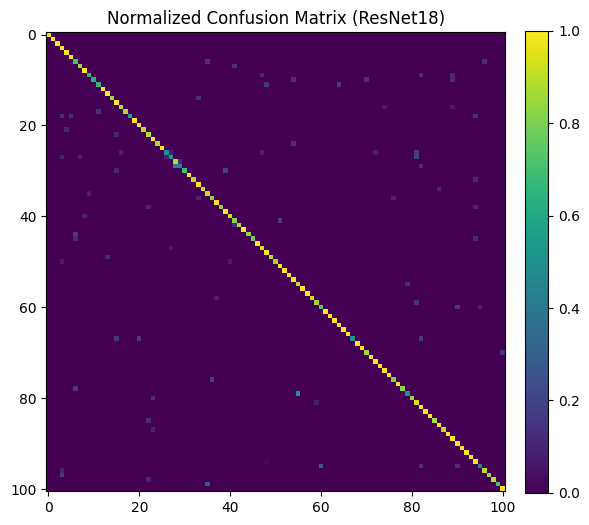

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os
os.makedirs("outputs/figures", exist_ok=True)

cm = confusion_matrix(y_true, y_pred)  # shape [101,101]
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,6))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (ResNet18)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()

plt.savefig("outputs/figures/resnet18_confusion_norm.png", dpi=200)
plt.show()

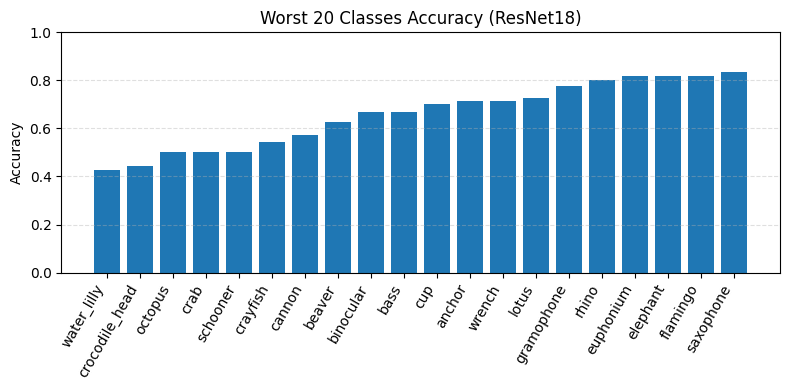

Worst 10: [('water_lilly', np.float64(0.42857142857142855)), ('crocodile_head', np.float64(0.4444444444444444)), ('octopus', np.float64(0.5)), ('crab', np.float64(0.5)), ('schooner', np.float64(0.5)), ('crayfish', np.float64(0.5454545454545454)), ('cannon', np.float64(0.5714285714285714)), ('beaver', np.float64(0.625)), ('binocular', np.float64(0.6666666666666666)), ('bass', np.float64(0.6666666666666666))]


In [29]:
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(class_names)
per_class_acc = np.zeros(num_classes)

for c in range(num_classes):
    mask = (y_true == c)
    per_class_acc[c] = (y_pred[mask] == c).mean() if mask.sum() > 0 else np.nan

# worst 20
worst_idx = np.argsort(per_class_acc)[:20]
worst_names = [class_names[i] for i in worst_idx]
worst_vals = per_class_acc[worst_idx]

plt.figure(figsize=(8,4))
plt.bar(worst_names, worst_vals)
plt.xticks(rotation=60, ha="right")
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Worst 20 Classes Accuracy (ResNet18)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("outputs/figures/resnet18_worst20.png", dpi=300)
plt.show()

print("Worst 10:", list(zip(worst_names[:10], worst_vals[:10])))

In [31]:
import pandas as pd
import numpy as np

cm = confusion_matrix(y_true, y_pred)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if cm_offdiag[i, j] > 0:
            pairs.append((class_names[i], class_names[j], cm_offdiag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:20]
df_pairs = pd.DataFrame(pairs, columns=["True", "Pred", "Count"])
df_pairs.to_csv("outputs/resnet18_top_confusions.csv", index=False)
df_pairs.head(10)

,True,Pred,Count
0,schooner,ketch,5
1,crocodile_head,crocodile,4
2,crab,scorpion,2
3,crayfish,scorpion,2
4,cup,ewer,2
5,flamingo,ibis,2
6,ketch,schooner,2
7,lotus,sunflower,2
8,rhino,elephant,2
9,water_lilly,lotus,2


In [32]:
from google.colab import files

files.download("outputs/resnet18_classification_report.txt")
files.download("outputs/figures/resnet18_confusion_norm.png")
files.download("outputs/figures/resnet18_worst20.png")
files.download("outputs/resnet18_top_confusions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>